**Part 1: Measuring Compilation Overhead**

In [ ]:
@jax.jit
def f(x):
    y = x ** 2
    y = jnp.sin(y)
    y = jnp.cos(y)
    y = jnp.exp(y)
    y = jnp.log(y * 100)
    y = jnp.square(y)
    y = jnp.sqrt(y + 14)
    y = jnp.tanh(y)
    y = jnp.abs(y)
    y = y + 5
    return y

Running for size: (100, 100)
  Eager time:      0.002676 s
  First JIT time:  0.085316 s
  Second JIT time: 0.000109 s

Running for size: (500, 500)
  Eager time:      0.183807 s
  First JIT time:  0.149925 s
  Second JIT time: 0.000158 s

Running for size: (1000, 1000)
  Eager time:      0.189298 s
  First JIT time:  0.226679 s
  Second JIT time: 0.000367 s

Running for size: (5000, 5000)
  Eager time:      0.282823 s
  First JIT time:  0.225222 s
  Second JIT time: 0.001550 s


Final Results:
Matrix Size  Eager           First JIT       Second JIT     
100x100      0.002676        0.085316        0.000109       
500x500      0.183807        0.149925        0.000158       
1000x1000    0.189298        0.226679        0.000367       
5000x5000    0.282823        0.225222        0.001550       


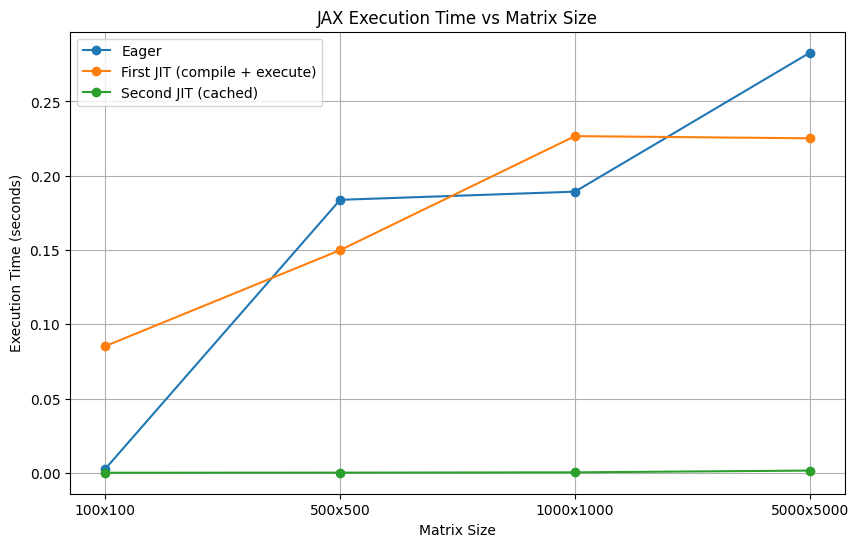

In [3]:
import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    y = x ** 2
    y = jnp.sin(y)
    y = jnp.cos(y)
    y = jnp.exp(y)
    y = jnp.log(y * 100)
    y = jnp.square(y)
    y = jnp.sqrt(y + 14)
    y = jnp.tanh(y)
    y = jnp.abs(y)
    y = y + 5
    return y

# Compute eager time
def measure_eager(fn, x, repeat=3):
    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        y = fn(x)
        y.block_until_ready()
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times)


# First JIT time
def measure_first_jit(fn, x):
    fn_jit = jax.jit(fn)
    start = time.perf_counter()
    y = fn_jit(x)
    y.block_until_ready()
    end = time.perf_counter()
    return end - start


# Second JIT time
def measure_second_jit(fn, x, repeat=3):
    fn_jit = jax.jit(fn)

    # First call: compile
    y = fn_jit(x)
    y.block_until_ready()

    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        y = fn_jit(x)
        y.block_until_ready()
        end = time.perf_counter()
        times.append(end - start)

    return np.mean(times)

# Test different size
matrix_sizes = [
    (100, 100),
    (500, 500),
    (1000, 1000),
    (5000, 5000)
]

# Store results
eager_times = []
first_jit_times = []
second_jit_times = []
labels = []

# Run experiments
for shape in matrix_sizes:
    print(f"Running for size: {shape}")

    x = jnp.array(np.random.rand(*shape).astype(np.float32) + 0.1)
    labels.append(f"{shape[0]}x{shape[1]}")

    eager_time = measure_eager(f, x, repeat=3)
    first_jit_time = measure_first_jit(f, x)
    second_jit_time = measure_second_jit(f, x, repeat=3)

    eager_times.append(eager_time)
    first_jit_times.append(first_jit_time)
    second_jit_times.append(second_jit_time)

    print(f"  Eager time:      {eager_time:.6f} s")
    print(f"  First JIT time:  {first_jit_time:.6f} s")
    print(f"  Second JIT time: {second_jit_time:.6f} s")
    print()


# Print results table
print("\nFinal Results:")
print("{:<12} {:<15} {:<15} {:<15}".format("Matrix Size", "Eager", "First JIT", "Second JIT"))

for i in range(len(labels)):
    print("{:<12} {:<15.6f} {:<15.6f} {:<15.6f}".format(
        labels[i],
        eager_times[i],
        first_jit_times[i],
        second_jit_times[i]
    ))


# Plot results
plt.figure(figsize=(10, 6))

plt.plot(labels, eager_times, marker='o', label='Eager')
plt.plot(labels, first_jit_times, marker='o', label='First JIT')
plt.plot(labels, second_jit_times, marker='o', label='Second JIT')

plt.xlabel("Matrix Size")
plt.ylabel("Execution Time (seconds)")
plt.title("JAX Execution Time vs Matrix Size")
plt.legend()
plt.grid(True)
plt.show()

**Why does the overhead vary with matrix size** The overhead varies with matrix size because JIT has a one-time compilation cost, while computation time grows with matrix size. For small matrices, compilation dominates the runtime, so eager mode may be faster. For large matrices, the compilation cost is amortized over more computation, so JIT becomes more beneficial. Moreover, JIT can reduce repeated kernel launches and memory traffic through optimization and operator fusion.

**Part 2: Shape Specialization**

Input 1, shape = (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 100.0:f32[]
  in (c,) }
----------------------------------------------------------------------
Input 2, shape = (100, 200)
{ lambda ; a:f32[100,200]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 200.0:f32[]
  in (c,) }
----------------------------------------------------------------------
Input 3, shape = (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 100.0:f32[]
  in (c,) }
----------------------------------------------------------------------
Input 4, shape = (200, 100)
{ lambda ; a:f32[200,100]. let
    b:f32[200] = reduce_sum[axes=(1,)] a
    c:f32[200] = div b 100.0:f32[]
  in (c,) }
----------------------------------------------------------------------
[0.05867788299997301, 0.055879728000036266, 0.000173162000010052, 0.05225697700007004]


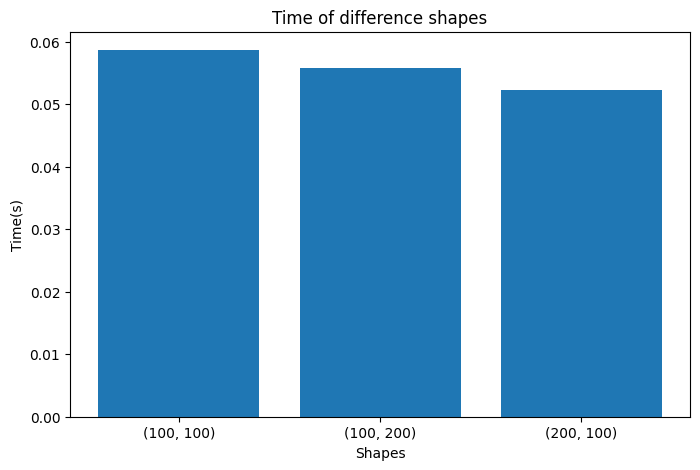

In [4]:
import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

@jax.jit
def mean(x):
    return jnp.mean(x, axis=1)
shapes = [(100, 100), (100, 200), (100, 100), (200, 100)]
inputs = [jnp.array(np.random.rand(*s).astype(np.float32)) for s in shapes]
for i, x in enumerate(inputs):
    print(f"Input {i+1}, shape = {x.shape}")
    print(jax.make_jaxpr(lambda z: jnp.mean(z, axis=1))(x))
    print("-" * 70)

times = []
for x in inputs:
    start = time.perf_counter()
    y = mean(x)
    y.block_until_ready()
    end = time.perf_counter()
    times.append(end - start)
print(times)

labels = [str(s) for s in shapes]
plt.figure(figsize=(8, 5))
plt.bar(labels, times)
plt.xlabel("Shapes")
plt.ylabel("Time(s)")
plt.title("Time of difference shapes")
plt.show()

 When does JAX retrace? What's the performance impact?
When JAX meet different shapes caused JAX retrace. It can be easily identified by time. When JAX meets the (100, 100), it needs 0.058, the shapes change to (100,200) with 0.0558. But the shapes return (100,100), the time reduce to 0.00017, which means the process doesn't need compilation, just use the first compilation. If it shows different shape again, the time becomes 0.05 again.

**Part 3: Operator Fusion Analysis**

In [5]:
import jax
import jax.numpy as jnp

def fusion_eager(x):
    total = jnp.zeros_like(x)
    for i in range(1, 101):
        s = x
        for _ in range(i):
            s = jnp.sin(s)

        c = x
        for _ in range(i):
            c = jnp.cos(c)

        total = total + s + c
    return total

@jax.jit
def fusion_jit(x):
    total = jnp.zeros_like(x)
    for i in range(1, 101):
        s = x
        for _ in range(i):
            s = jnp.sin(s)

        c = x
        for _ in range(i):
            c = jnp.cos(c)

        total = total + s + c
    return total

import time
import numpy as np

x = jnp.array(np.random.rand(1000, 1000).astype(np.float32))

# Eager timing
start = time.perf_counter()
y = fusion_eager(x)
y.block_until_ready()
end = time.perf_counter()
eager_time = end - start

# First JIT call
start = time.perf_counter()
y = fusion_jit(x)
y.block_until_ready()
end = time.perf_counter()
first_jit_time = end - start

# Second JIT call
start = time.perf_counter()
y = fusion_jit(x)
y.block_until_ready()
end = time.perf_counter()
second_jit_time = end - start

print("Eager:", eager_time)
print("First JIT:", first_jit_time)
print("Second JIT:", second_jit_time)


Eager: 1.0937938850001956
First JIT: 21.29918014499981
Second JIT: 0.00937239299992143


Explain the results. Why does the JIT version achieve better performance? How many operations were fused together? What's the theoretical vs actual speedup?
The JIT version can perform better because it can  do operation fusion. it can fuse elementwise operations into a smaller number of kernels. This reduce kernel launch overhead and avoids repeatedly writing IR to DRAM.